<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Predicted Species: ['virginica']


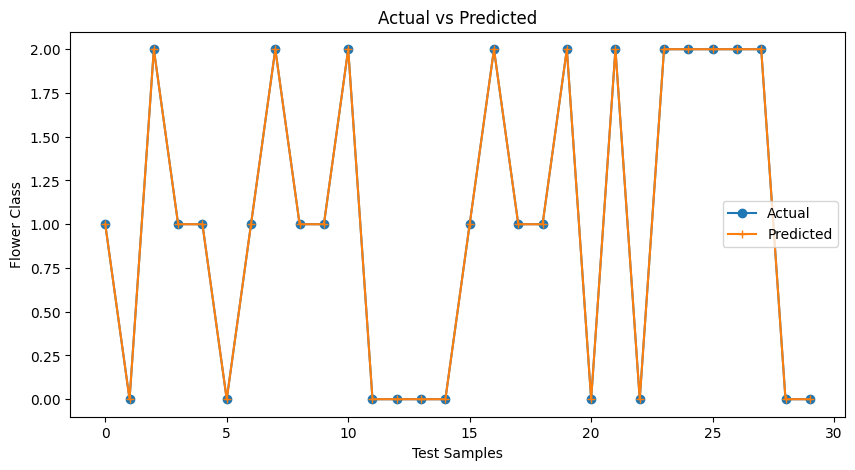

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

df = pd.read_csv(r"C:\Users\kabilesh\Downloads\archive (4).zip")
print(df.info())

# Label Encoding 
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# Features and Target
X = df.drop('species', axis=1)
y = df['species']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Logistic Regression Model
model = LogisticRegression()

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Predict New Data
new_data = pd.DataFrame( [[6.3, 3.5, 5.4, 1.5]], columns=X.columns)

prediction = model.predict(new_data)
predicted_class = le.inverse_transform(prediction)

print("Predicted Species:", predicted_class)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, marker='o', label='Actual')
plt.plot(y_pred, marker='+', label='Predicted')
plt.title("Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Flower Class")
plt.legend()

plt.show()
